In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from src.SizeEffects_functions import linear_regression_weighted
from matplotlib.collections import LineCollection
from src.process_data import  process_all_data, create_folder
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
plt.style.use('properties.mplstyle')

In [2]:
results_folder = "../results/Density/3D/"
#path_sizes = "../results/size_effects/3D/"

create_folder(results_folder)
#create_folder(path_sizes)

In [3]:
df = pd.read_csv("../SOP_data/all_data.dat", sep = ' ')
df

,type_perc,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,bond,2,128,2,0.00001,1,1.000,1.0,0.1,1,600,600,0.864485,0.000007,130.770000,0.039057,15724.353333,5.101384
1,bond,2,128,5,0.00001,1,1.000,1.0,0.1,1,600,600,0.867833,0.000007,130.631667,0.036682,15724.226667,4.842578
2,bond,2,256,5,0.00001,1,1.000,1.0,0.1,1,400,306,0.499460,0.000031,342.960784,1.033260,54616.777778,37.916007
3,bond,2,128,7,0.00001,1,1.000,1.0,0.1,1,600,600,0.870005,0.000008,130.541667,0.038797,15724.835000,5.188671
4,bond,2,128,10,0.00001,1,1.000,1.0,0.1,1,600,600,0.872239,0.000008,130.370000,0.037294,15716.511667,5.113005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19437,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,4,10,10,1.000000,0.000000,1022.000000,0.000000,35474.800000,647.639317
19438,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,5,10,10,1.000000,0.000000,1022.000000,0.000000,30872.900000,911.686623
19439,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,6,10,10,1.000000,0.000000,1022.000000,0.000000,25762.700000,817.995016
19440,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,7,10,10,1.000000,0.000000,1022.000000,0.000000,24127.400000,701.424522


     type_perc  dim    L    Nt         k  nc  rho   p0   P0  order  N_samples  \
3783      bond    3  512  7864  0.000001   2  0.5  1.0  0.1      1         95   

      N_samples_perc    p_mean     p_err  shortest_path  shortest_path_err  \
3783              95  0.253381  0.000005    2047.021053           5.124518   

            S_perc    S_perc_err  
3783  1.684440e+07  40270.944572  


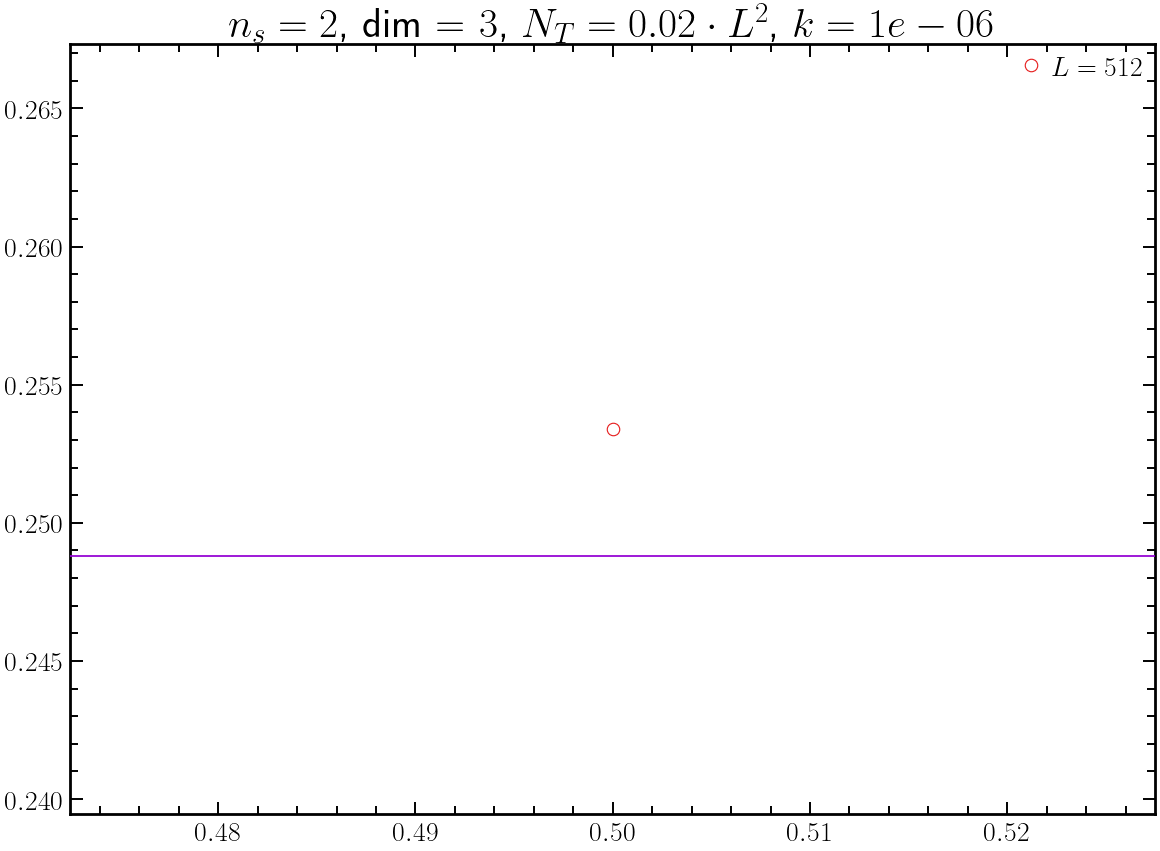

In [16]:
nc = 2
p0 = 1.0
P0 = 0.1
if nc == 2:
    f0 = 0.03
elif nc == 4:
    f0 = 0.02
elif nc == 8:
    f0 = 0.01

L_lst = [512]
dim = 3
k = 1.0e-06
ord = 1
#df[(df["L"]==L) & (df['dim']==dim) & (df["Nt"]==int(f0*L**2)) & (df['nc']==nc) & (df['k']==k) & (df['order']==ord)]
lw = 2.0
pc = 0.24881182
lw_pc = 1.4
for L in L_lst:
    df_sub = df[(df['nc']==nc) & (df['dim']==dim) & (df['L']==L) & (df["Nt"]==int(f0*L**2)) & (df["P0"]==P0) & (df['order']==1) & (df['p0']==p0) & (df['k']==k)]
    print(df_sub)
    plt.plot(df_sub['rho'], df_sub['p_mean'], 'o' ,label=f"$L = {L}$")

plt.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
# pc_node = 0.31160768
# plt.axhline(y=pc_node, linestyle="-", color="k", lw=lw_pc, alpha=0.9, zorder=5)
plt.legend(fontsize=20)
plt.title(f"$n_s = {nc}$, dim = ${dim}$, $N_T = 0.02 \\cdot L^2$, $k = {k}$", fontsize=30)
#plt.savefig("rho_ns_4.png")
plt.show()